# Week 3 — Multimodal Sensor Fusion for Companion AI

This notebook adapts a three-modality presentation analysis pipeline to a companion robot context inspired by InGen Dynamics' Fari platform.

The pipeline combines:

1. **Audio features** — MFCC-based acoustic features extracted with `librosa`
2. **Visual features** — facial geometry/expression features extracted from an image
3. **Text features** — sentence embeddings generated with `sentence-transformers`

The three feature vectors are fused using early concatenation and used to train a binary classifier for a synthetic **distress vs. normal interaction** task.

Evaluation is performed on a held-out test set using precision, recall, F1 score, and AUROC. Single-modality ablation experiments are also used to examine which modality contributes most to classifier performance.

> This notebook uses only public or synthetic data. It does not use InGen internal systems, proprietary data, or real Fari user data.



In [1]:
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import cv2

from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("librosa:", librosa.__version__)
print("OpenCV:", cv2.__version__)

c:\Users\User\Desktop\work\ingen-mlnn-week1-starter\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.9
NumPy: 2.4.6
librosa: 0.11.0
OpenCV: 5.0.0


## 1. Reproducibility

A fixed random seed is used for synthetic data generation, train/test splitting, and classifier training so that the reported results can be reproduced.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")


Random seed set to 42


## 2. Audio Modality — MFCC Features

For the audio modality, the pipeline uses Mel-frequency cepstral coefficients (MFCCs).

MFCCs provide a compact representation of the spectral characteristics of speech. For each audio sample, 13 MFCC coefficients are extracted across time. The mean and standard deviation of each coefficient are then computed, producing a fixed-length 26-dimensional feature vector.

In the Fari companion context, this modality represents information contained in an elder user's speech signal, such as changes in vocal characteristics and acoustic dynamics.


In [3]:
def extract_audio_features(
    audio: np.ndarray,
    sample_rate: int,
    n_mfcc: int = 13,
) -> np.ndarray:
    """
    Extract a fixed-length MFCC feature vector from an audio waveform.

    Returns:
        26-dimensional vector:
        13 MFCC means + 13 MFCC standard deviations.
    """
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=n_mfcc,
    )

    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    return np.concatenate([mfcc_mean, mfcc_std])

print("Audio feature extractor defined.")

Audio feature extractor defined.


### Audio Feature Extraction Sanity Check

A short synthetic waveform is used below only to verify that the MFCC extraction pipeline produces the expected fixed-length representation.

In [4]:
SAMPLE_RATE = 16000
DURATION = 2.0

t = np.linspace(
    0,
    DURATION,
    int(SAMPLE_RATE * DURATION),
    endpoint=False,
)

test_audio = (
    0.5 * np.sin(2 * np.pi * 180 * t)
    + 0.2 * np.sin(2 * np.pi * 320 * t)
)

test_audio_features = extract_audio_features(
    test_audio.astype(np.float32),
    SAMPLE_RATE,
)

print("Audio waveform shape:", test_audio.shape)
print("Audio feature shape:", test_audio_features.shape)
print("First five features:")
print(test_audio_features[:5])


Audio waveform shape: (32000,)
Audio feature shape: (26,)
First five features:
[-462.02032    63.496056   50.201637   40.805214   29.69764 ]


Raw MFCC matrix shape: (13, 63)


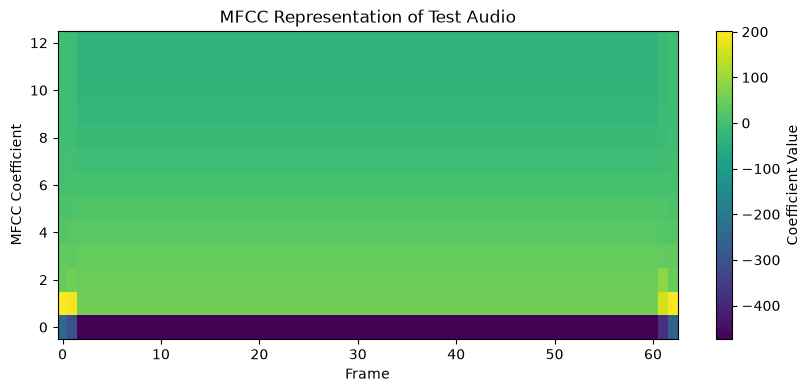

In [5]:
test_mfcc = librosa.feature.mfcc(
    y=test_audio.astype(np.float32),
    sr=SAMPLE_RATE,
    n_mfcc=13,
)

print("Raw MFCC matrix shape:", test_mfcc.shape)

plt.figure(figsize=(10, 4))
plt.imshow(test_mfcc, aspect="auto", origin="lower")
plt.xlabel("Frame")
plt.ylabel("MFCC Coefficient")
plt.title("MFCC Representation of Test Audio")
plt.colorbar(label="Coefficient Value")
plt.show()

## 3. Visual Modality — Facial Geometry Features

For the visual modality, the pipeline represents facial expression information using a compact set of facial geometry features.

A real Fari deployment could extract facial landmarks from camera frames using MediaPipe or OpenCV. In this notebook, the downstream classifier uses synthetic facial geometry measurements so that the experiment remains reproducible and does not require real user images.

The selected features describe expression-relevant relationships around the eyes, eyebrows, and mouth. These measurements provide a fixed-length representation that can later be fused with the audio and text modalities.

In [6]:
VISUAL_FEATURE_NAMES = [
    "left_eye_openness",
    "right_eye_openness",
    "left_brow_height",
    "right_brow_height",
    "mouth_openness",
    "mouth_corner_asymmetry",
]

print("Visual feature count:", len(VISUAL_FEATURE_NAMES))
print("Visual features:")
for name in VISUAL_FEATURE_NAMES:
    print("-", name)

Visual feature count: 6
Visual features:
- left_eye_openness
- right_eye_openness
- left_brow_height
- right_brow_height
- mouth_openness
- mouth_corner_asymmetry


In [7]:
def euclidean_distance(point_a, point_b):
    """Compute Euclidean distance between two 2D points."""
    point_a = np.asarray(point_a, dtype=float)
    point_b = np.asarray(point_b, dtype=float)
    return np.linalg.norm(point_a - point_b)


def extract_visual_geometry(landmarks: dict) -> np.ndarray:
    """
    Convert selected 2D facial landmarks into a compact
    expression-related feature vector.

    Expected landmark keys:
        left_eye_top, left_eye_bottom
        right_eye_top, right_eye_bottom
        left_brow, right_brow
        left_eye_center, right_eye_center
        upper_lip, lower_lip
        left_mouth_corner, right_mouth_corner
    """

    left_eye_openness = euclidean_distance(
        landmarks["left_eye_top"],
        landmarks["left_eye_bottom"],
    )

    right_eye_openness = euclidean_distance(
        landmarks["right_eye_top"],
        landmarks["right_eye_bottom"],
    )

    left_brow_height = euclidean_distance(
        landmarks["left_brow"],
        landmarks["left_eye_center"],
    )

    right_brow_height = euclidean_distance(
        landmarks["right_brow"],
        landmarks["right_eye_center"],
    )

    mouth_openness = euclidean_distance(
        landmarks["upper_lip"],
        landmarks["lower_lip"],
    )

    left_corner = np.asarray(landmarks["left_mouth_corner"], dtype=float)
    right_corner = np.asarray(landmarks["right_mouth_corner"], dtype=float)

    mouth_corner_asymmetry = abs(left_corner[1] - right_corner[1])

    return np.array(
        [
            left_eye_openness,
            right_eye_openness,
            left_brow_height,
            right_brow_height,
            mouth_openness,
            mouth_corner_asymmetry,
        ],
        dtype=np.float32,
    )

### Visual Feature Extraction Sanity Check

The following synthetic landmark configuration is used only to verify that the facial geometry extractor returns a consistent fixed-length feature vector. These coordinates do not represent a real Fari user or a clinically meaningful facial state.

In [8]:
test_landmarks = {
    "left_eye_top": (0.30, 0.38),
    "left_eye_bottom": (0.30, 0.42),
    "right_eye_top": (0.70, 0.38),
    "right_eye_bottom": (0.70, 0.42),

    "left_brow": (0.30, 0.30),
    "right_brow": (0.70, 0.30),

    "left_eye_center": (0.30, 0.40),
    "right_eye_center": (0.70, 0.40),

    "upper_lip": (0.50, 0.65),
    "lower_lip": (0.50, 0.70),

    "left_mouth_corner": (0.40, 0.68),
    "right_mouth_corner": (0.60, 0.67),
}

test_visual_features = extract_visual_geometry(test_landmarks)

print("Visual feature shape:", test_visual_features.shape)

for name, value in zip(
    VISUAL_FEATURE_NAMES,
    test_visual_features,
):
    print(f"{name}: {value:.4f}")

Visual feature shape: (6,)
left_eye_openness: 0.0400
right_eye_openness: 0.0400
left_brow_height: 0.1000
right_brow_height: 0.1000
mouth_openness: 0.0500
mouth_corner_asymmetry: 0.0100


### Visual Modality Design Note

In a deployed companion robot, these geometry measurements would be computed from facial landmarks detected directly from camera frames. For this portfolio experiment, the classifier dataset uses synthetic geometry values rather than real faces because no Fari interaction dataset is available.

This separation keeps the experiment reproducible while preserving the intended pipeline structure:

**camera frame → facial landmarks → geometry features → multimodal fusion**

The synthetic values should therefore be interpreted as a proof-of-concept representation, not as validated indicators of human distress.

## 4. Text Modality — Sentence Embeddings

The language modality represents the semantic content of the user's most recent conversational turn.

A pre-trained `all-MiniLM-L6-v2` sentence transformer maps each text input to a 384-dimensional embedding. Unlike keyword counts, sentence embeddings encode semantic information in a continuous vector representation and can therefore be concatenated with the audio and visual features.

In the Fari context, this modality represents what the user says, while the audio and visual modalities provide complementary information about how the utterance is expressed.

In [9]:
TEXT_MODEL_NAME = "all-MiniLM-L6-v2"

text_model = SentenceTransformer(TEXT_MODEL_NAME)

print("Loaded text model:", TEXT_MODEL_NAME)
print(
    "Embedding dimension:",
    text_model.get_sentence_embedding_dimension(),
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8461.23it/s]


Loaded text model: all-MiniLM-L6-v2
Embedding dimension: 384


C:\Users\User\AppData\Local\Temp\ipykernel_52300\1292611257.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  text_model.get_sentence_embedding_dimension(),


In [10]:
def extract_text_features(text: str) -> np.ndarray:
    """Encode one dialogue turn as a sentence embedding."""
    embedding = text_model.encode(
        text,
        convert_to_numpy=True,
    )

    return embedding.astype(np.float32)


test_text = "I feel confused and I am not sure where I am."

test_text_features = extract_text_features(test_text)

print("Example text:", test_text)
print("Text feature shape:", test_text_features.shape)
print("First five embedding values:")
print(test_text_features[:5])

Example text: I feel confused and I am not sure where I am.
Text feature shape: (384,)
First five embedding values:
[ 0.00050484 -0.08297419  0.06240762 -0.00586954  0.05636738]


## 5. Synthetic Multimodal Dataset

Because no real Fari companion interaction dataset is available, this experiment uses a small synthetic dataset with explicit label-generation rules.

The dataset contains 80 multimodal interactions:

- 40 **normal** interactions
- 40 **distress** interactions

Each interaction contains:

- a synthetic two-second audio waveform,
- synthetic facial geometry measurements,
- a unique conversational text turn.

The two classes are generated from overlapping distributions rather than perfectly separated rules. This makes the classification task less trivial while still allowing the pipeline to test whether the three modalities provide useful complementary information.

These synthetic labels are experimental proxies only. They should not be interpreted as validated indicators of real human distress.

In [11]:
normal_openings = [
    "I am feeling",
    "Today I feel",
    "I have been feeling",
    "Right now I feel",
    "This morning I feel",
    "At the moment I am",
    "I would say I feel",
    "I think I am feeling",
    "Everything feels",
    "I am doing",
]

normal_endings = [
    "comfortable and relaxed.",
    "fine and ready for the day.",
    "calm after resting for a while.",
    "okay and I know what I want to do.",
]

distress_openings = [
    "I am feeling",
    "Right now I feel",
    "I have been feeling",
    "I think I am",
    "This morning I feel",
    "At the moment I am",
    "I do not understand why I feel",
    "I am not sure why I am",
    "Everything feels",
    "I keep feeling",
]

distress_endings = [
    "confused and unsure about where I am.",
    "uneasy and I do not know what to do.",
    "overwhelmed and unable to focus clearly.",
    "worried because things around me seem unfamiliar.",
]

normal_texts = [
    f"{opening} {ending}"
    for opening in normal_openings
    for ending in normal_endings
]

distress_texts = [
    f"{opening} {ending}"
    for opening in distress_openings
    for ending in distress_endings
]

print("Normal text samples:", len(normal_texts))
print("Distress text samples:", len(distress_texts))

print("\nNormal example:")
print(normal_texts[0])

print("\nDistress example:")
print(distress_texts[0])

Normal text samples: 40
Distress text samples: 40

Normal example:
I am feeling comfortable and relaxed.

Distress example:
I am feeling confused and unsure about where I am.


### Synthetic Audio Generation

The audio samples are synthetic acoustic proxies rather than realistic speech recordings.

Normal samples are generated with relatively stable frequency and amplitude characteristics. Distress labelled samples use somewhat greater amplitude modulation, frequency variation, and noise. The distributions intentionally overlap so that the label cannot be recovered from a single deterministic threshold.

The generated waveform is then passed through the same MFCC extractor defined earlier.

In [12]:
def generate_synthetic_audio(label: int) -> np.ndarray:
    """
    Generate a two-second synthetic acoustic signal.

    label = 0: normal
    label = 1: distress
    """
    t = np.linspace(
        0,
        DURATION,
        int(SAMPLE_RATE * DURATION),
        endpoint=False,
    )

    if label == 0:
        base_frequency = np.random.normal(180, 18)
        amplitude = np.random.normal(0.45, 0.06)
        modulation_depth = np.random.uniform(0.02, 0.12)
        noise_level = np.random.uniform(0.005, 0.025)

    else:
        base_frequency = np.random.normal(205, 25)
        amplitude = np.random.normal(0.50, 0.08)
        modulation_depth = np.random.uniform(0.08, 0.22)
        noise_level = np.random.uniform(0.015, 0.045)

    modulation_frequency = np.random.uniform(1.5, 4.0)

    amplitude_envelope = (
        1
        + modulation_depth
        * np.sin(2 * np.pi * modulation_frequency * t)
    )

    signal = (
        amplitude
        * amplitude_envelope
        * np.sin(2 * np.pi * base_frequency * t)
    )

    signal += (
        0.20
        * amplitude
        * np.sin(2 * np.pi * 2 * base_frequency * t)
    )

    signal += np.random.normal(
        0,
        noise_level,
        size=t.shape,
    )

    return signal.astype(np.float32)

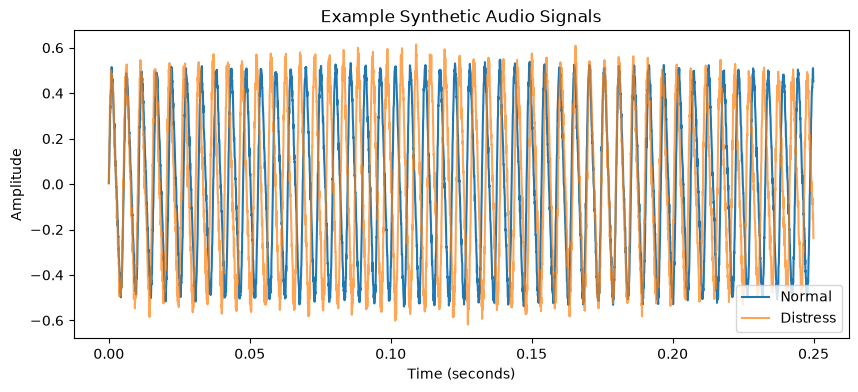

In [13]:
normal_audio_example = generate_synthetic_audio(label=0)
distress_audio_example = generate_synthetic_audio(label=1)

time_axis = np.arange(len(normal_audio_example)) / SAMPLE_RATE

plt.figure(figsize=(10, 4))
plt.plot(
    time_axis[:4000],
    normal_audio_example[:4000],
    label="Normal",
)
plt.plot(
    time_axis[:4000],
    distress_audio_example[:4000],
    label="Distress",
    alpha=0.7,
)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Example Synthetic Audio Signals")
plt.legend()
plt.show()

### Synthetic Visual Geometry Generation

The visual modality is generated as six normalized facial geometry measurements.

The normal and distress-labelled classes use overlapping distributions. Distress-labelled samples have modest shifts in features such as mouth openness and mouth corner asymmetry, but no single visual feature deterministically defines the label.

These values simulate the output of a facial-landmark geometry pipeline; they are not claims about real clinical or emotional facial behaviour.

In [14]:
def generate_synthetic_visual_features(label: int) -> np.ndarray:
    """
    Generate six synthetic normalized facial geometry features.

    label = 0: normal
    label = 1: distress
    """

    if label == 0:
        features = np.array(
            [
                np.random.normal(0.040, 0.009),
                np.random.normal(0.040, 0.009),
                np.random.normal(0.100, 0.018),
                np.random.normal(0.100, 0.018),
                np.random.normal(0.050, 0.014),
                np.random.normal(0.012, 0.008),
            ]
        )

    else:
        features = np.array(
            [
                np.random.normal(0.046, 0.012),
                np.random.normal(0.046, 0.012),
                np.random.normal(0.115, 0.022),
                np.random.normal(0.115, 0.022),
                np.random.normal(0.068, 0.020),
                np.random.normal(0.030, 0.016),
            ]
        )

    features = np.clip(features, 0.0, None)

    return features.astype(np.float32)

In [15]:
normal_visual_example = generate_synthetic_visual_features(label=0)
distress_visual_example = generate_synthetic_visual_features(label=1)

visual_example_df = pd.DataFrame(
    {
        "Feature": VISUAL_FEATURE_NAMES,
        "Normal Example": normal_visual_example,
        "Distress Example": distress_visual_example,
    }
)

visual_example_df

,Feature,Normal Example,Distress Example
0,left_eye_openness,0.022140,0.063434
1,right_eye_openness,0.039521,0.065025
2,left_brow_height,0.101308,0.096644
3,right_brow_height,0.121772,0.099915
4,mouth_openness,0.028845,0.034007
5,mouth_corner_asymmetry,0.009736,0.000000


### Constructing the 80-Interaction Dataset

Each synthetic interaction is converted into modality specific features using the same feature representations used throughout the notebook.

The audio waveform is converted to 26 MFCC summary features, the visual channel contributes six geometry features, and the text channel is encoded as a 384-dimensional MiniLM sentence embedding.

In [16]:
NUM_SAMPLES_PER_CLASS = 40

labels = np.array(
    [0] * NUM_SAMPLES_PER_CLASS
    + [1] * NUM_SAMPLES_PER_CLASS
)

texts = normal_texts + distress_texts

audio_features_list = []
visual_features_list = []

for label in labels:
    audio = generate_synthetic_audio(label)

    audio_features = extract_audio_features(
        audio,
        SAMPLE_RATE,
    )

    visual_features = generate_synthetic_visual_features(
        label
    )

    audio_features_list.append(audio_features)
    visual_features_list.append(visual_features)

audio_features_all = np.vstack(audio_features_list)
visual_features_all = np.vstack(visual_features_list)

print("Audio feature matrix:", audio_features_all.shape)
print("Visual feature matrix:", visual_features_all.shape)
print("Labels:", labels.shape)
print("Texts:", len(texts))

Audio feature matrix: (80, 26)
Visual feature matrix: (80, 6)
Labels: (80,)
Texts: 80


In [17]:
text_features_all = text_model.encode(
    texts,
    convert_to_numpy=True,
    show_progress_bar=True,
).astype(np.float32)

print("Text feature matrix:", text_features_all.shape)

Batches: 100%|██████████| 3/3 [00:00<00:00, 36.78it/s]

Text feature matrix: (80, 384)


## 6. Early Multimodal Fusion

The three modality specific feature matrices are concatenated along the feature dimension.

For each interaction:

- Audio: 26 dimensions
- Visual: 6 dimensions
- Text: 384 dimensions

The resulting fused representation therefore contains 416 features per interaction.

This is an early-fusion approach because the modality features are combined before classifier training.

In [18]:
X_fused = np.concatenate(
    [
        audio_features_all,
        visual_features_all,
        text_features_all,
    ],
    axis=1,
)

y = labels.copy()

print("Audio dimensions:", audio_features_all.shape[1])
print("Visual dimensions:", visual_features_all.shape[1])
print("Text dimensions:", text_features_all.shape[1])
print("Fused feature matrix:", X_fused.shape)
print("Label vector:", y.shape)

Audio dimensions: 26
Visual dimensions: 6
Text dimensions: 384
Fused feature matrix: (80, 416)
Label vector: (80,)


In [19]:
dataset_summary = pd.DataFrame(
    {
        "Modality": ["Audio", "Visual", "Text", "Fused"],
        "Samples": [
            audio_features_all.shape[0],
            visual_features_all.shape[0],
            text_features_all.shape[0],
            X_fused.shape[0],
        ],
        "Features": [
            audio_features_all.shape[1],
            visual_features_all.shape[1],
            text_features_all.shape[1],
            X_fused.shape[1],
        ],
    }
)

dataset_summary

,Modality,Samples,Features
0,Audio,80,26
1,Visual,80,6
2,Text,80,384
3,Fused,80,416


## 7. Held-Out Train/Test Split

The dataset is divided into an 80/20 stratified train/test split. The held-out test set is not used during classifier fitting.

A stratified split preserves the balance between the normal and distress classes.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fused,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)

Training samples: (64, 416)
Test samples: (16, 416)
Training labels: (64,)
Test labels: (16,)


## 8. Multimodal Classifier

A logistic regression classifier is used as a simple and interpretable baseline for the fused multimodal representation.

Feature standardization is performed using `StandardScaler`. The scaler is fitted only on the training data as part of the scikit-learn pipeline, preventing information from the held-out test set from leaking into training.

In [21]:
fusion_classifier = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                random_state=SEED,
                max_iter=2000,
            ),
        ),
    ]
)

fusion_classifier.fit(X_train, y_train)

print("Fusion classifier trained.")

Fusion classifier trained.


In [22]:
y_pred = fusion_classifier.predict(X_test)
y_prob = fusion_classifier.predict_proba(X_test)[:, 1]

fusion_accuracy = accuracy_score(y_test, y_pred)
fusion_precision = precision_score(y_test, y_pred)
fusion_recall = recall_score(y_test, y_pred)
fusion_f1 = f1_score(y_test, y_pred)
fusion_auroc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {fusion_accuracy:.3f}")
print(f"Precision: {fusion_precision:.3f}")
print(f"Recall:    {fusion_recall:.3f}")
print(f"F1 Score:  {fusion_f1:.3f}")
print(f"AUROC:     {fusion_auroc:.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Distress"],
    )
)

Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
AUROC:     1.000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         8
    Distress       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



## 9. Modality Ablation Analysis

To estimate the contribution of each modality, the same classifier configuration is trained independently on audio-only, visual-only, text-only, and full multimodal representations.

The same train/test indices are used for every experiment so that the resulting metrics are directly comparable.

In [23]:
indices = np.arange(len(y))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

def evaluate_modality(X, name):
    X_train_mod = X[train_indices]
    X_test_mod = X[test_indices]

    y_train_mod = y[train_indices]
    y_test_mod = y[test_indices]

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    random_state=SEED,
                    max_iter=2000,
                ),
            ),
        ]
    )

    model.fit(X_train_mod, y_train_mod)

    predictions = model.predict(X_test_mod)
    probabilities = model.predict_proba(X_test_mod)[:, 1]

    return {
        "Modality": name,
        "Accuracy": accuracy_score(y_test_mod, predictions),
        "Precision": precision_score(y_test_mod, predictions),
        "Recall": recall_score(y_test_mod, predictions),
        "F1": f1_score(y_test_mod, predictions),
        "AUROC": roc_auc_score(y_test_mod, probabilities),
    }

In [24]:
ablation_results = [
    evaluate_modality(
        audio_features_all,
        "Audio Only",
    ),
    evaluate_modality(
        visual_features_all,
        "Visual Only",
    ),
    evaluate_modality(
        text_features_all,
        "Text Only",
    ),
    evaluate_modality(
        X_fused,
        "Audio + Visual + Text",
    ),
]

ablation_df = pd.DataFrame(ablation_results)

ablation_df.round(3)

,Modality,Accuracy,Precision,Recall,F1,AUROC
0,Audio Only,0.875,0.875,0.875,0.875,0.984
1,Visual Only,1.000,1.000,1.000,1.000,1.000
2,Text Only,1.000,1.000,1.000,1.000,1.000
3,Audio + Visual + Text,1.000,1.000,1.000,1.000,1.000


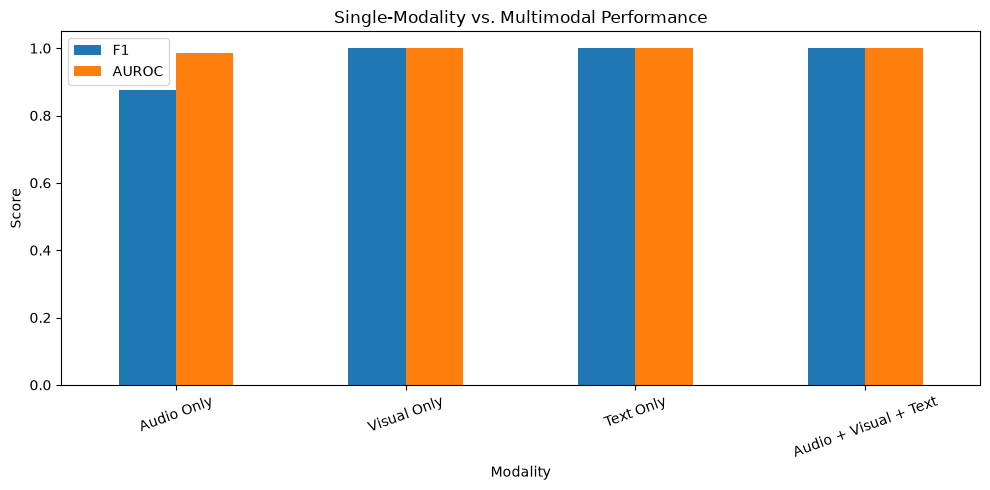

In [25]:
plot_df = ablation_df.set_index("Modality")

plot_df[["F1", "AUROC"]].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Single-Modality vs. Multimodal Performance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [26]:
single_modality_df = ablation_df.iloc[:3]

best_single_row = single_modality_df.loc[
    single_modality_df["F1"].idxmax()
]

best_modality = best_single_row["Modality"]
best_f1 = best_single_row["F1"]

print("Best single modality:", best_modality)
print(f"Best single-modality F1: {best_f1:.3f}")
print(f"Fusion F1: {fusion_f1:.3f}")

Best single modality: Visual Only
Best single-modality F1: 1.000
Fusion F1: 1.000


## 10. Results Interpretation

The ablation experiment compares each individual modality against the complete early-fusion representation.

Because this experiment uses a small synthetic dataset with explicit class generation rules, the reported metrics measure whether the proof-of-concept pipeline can recover patterns embedded in the synthetic distributions. They should not be interpreted as estimates of real world Fari distress detection accuracy.

Differences between the single-modality results indicate how much class information was encoded in the synthetic audio, visual, and language distributions. The multimodal result indicates whether combining these feature types provides additional predictive signal over individual modalities.

## 11. Limitations

This experiment has several important limitations.

First, the dataset is synthetic and contains only 80 examples. The normal and distress labels are generated from manually designed distributions rather than real companion robot observations.

Second, the audio signals are synthetic acoustic proxies rather than natural human speech, and the visual features are synthetic facial geometry measurements rather than landmarks extracted from real camera frames.

Third, the text examples are manually constructed. Although their embeddings are produced by a real pre-trained transformer, their vocabulary and semantic structure may make the two classes easier to separate than naturally occurring dialogue.

Finally, this system performs binary classification of isolated interactions. A real companion robot would require temporal context, user specific baselines, uncertainty calibration, privacy safeguards, and careful human evaluation before any safety sensitive deployment.

The results should therefore be viewed as validation of the multimodal pipeline architecture rather than validation of a real-world distress detector.

## 12. Conclusion

This notebook implemented a proof of concept three modality companion AI pipeline consisting of:

- 26-dimensional MFCC audio features,
- 6-dimensional facial geometry features,
- 384-dimensional MiniLM sentence embeddings,
- early feature fusion,
- logistic regression classification,
- held-out evaluation, and
- single-modality ablation analysis.

The experiment demonstrates how an existing multimodal analysis workflow can be transferred into a companion robot sensor fusion context while maintaining a clear separation between feature extraction, fusion, classification, and evaluation.

The resulting performance should be interpreted only within the synthetic experimental setting. The most important outcome is the reproducible multimodal engineering pipeline and the analysis of how different sensor modalities contribute to the final prediction.